# 读取WAY-EEG-GAL 数据集

In [1]:
import scipy.io as sio
import torch
import matplotlib.pyplot as plt
import numpy as np
import time 

## 加载数据(Windows Structure)

In [2]:
# 指定文件
structure = 'WS'    # 当前此文件仅用来 load WS
participant = 'P1'   # 受试
series = 'S1'        # 

In [3]:
file_path = f'{participant}/{structure}_{participant}_{series}.mat'
print(f'已加载的路径为：“{file_path}”')

已加载的路径为：“P1/WS_P1_S1.mat”


In [4]:
mat_data = sio.loadmat(file_path) 
#print('hs.type:',type(mat_data['ws']))
#print('len:',len(mat_data['ws'][0,0]))

## 重构数据

In [5]:
from dataclasses import dataclass, field
from typing import List, Optional

In [6]:
"""定义结构类型,参考matlab中原数据结构"""
@dataclass
class NamesModule:
    """names结构，对应matlab中的数据结构"""
    eeg: List[str]      # eeg 通道名称
    kin: List[str]      # kin 通道名称
    emg: List[str]      # emg 通道名称

@dataclass
class DataModule:
    """"Data结构，新建，存储np.array和tensor"""
    array: np.ndarray                     # np格式
    tensor: torch.Tensor  # 后续转为 PyTorch tensor

@dataclass
class WinModule:
    """win结构，对应matlab中的数据结构"""
    eeg: DataModule      # eeg 信号矩阵
    kin: DataModule      # 运动学 + 动力学信号
    emg: DataModule      # EMG 信号矩阵
    eeg_t: DataModule    # EEG 和 kin 信号对应的绝对时间向量
    emg_t: DataModule    # EMG 信号对应的绝对时间向量
    trial_start_time: np.float32  # 本次试验窗口的绝对起始时间
    LEDon: int           # LED 亮起时刻
    LEDoff: np.float32   # LED 熄灭时刻
    trial_end_time: np.float32   # 本次试验窗口的绝对结束时间
    weight: int          # 当前物体重量代码
    weight_id: str       # 当前物体重量文字描述
    surf: int            # 当前接触表面代码（1=sandpaper, 2=suede, 3=silk）
    surf_id: str         # 当前接触表面文字描述
    weight_prev: int     # 上一次试验的重量代码
    weight_prev_id: str  # 上一次试验的重量文字描述
    surf_prev: int       # 上一次试验的表面代码
    surf_prev_id: str    # 上一次试验的表面文字描述
    
@dataclass
class WSData:
    """最顶层ws结构，对应matlab中的数据结构"""
    name: str                 # 受试者名称
    participant: int          # 受试者编号
    series: int               # 系列编号
    names: NamesModule        # 各通道名称
    win: WinModule            # 窗口结构数据

In [7]:
"""自定义结构的数据构建方法，由mat格式转换为array和tensor"""
def build_ws_data(mat_data) -> WSData:
    """data->ws的转换函数"""
    ws_struct = mat_data['ws'][0,0]
    # ws_struct 是 tuple of 5 structured arrays
    name, participant, series, names, win = ws_struct

    def data_extract_module(arr):
        # data 结构的数据映射
        array = arr
        tensor = torch.from_numpy(arr.astype(np.float32))
        return DataModule(
            array=array, 
            tensor=tensor
        )
        
    def win_extract_module(arr):
        # win 结构的数据映射
        eeg_array = np.array([arr[0, i][0][0:4000] for i in range(34)])
        kin_array = np.array([arr[0, i][1][0:4000] for i in range(34)])
        emg_array = np.array([arr[0, i][2][0:32000] for i in range(34)])
        eeg_t_array = np.array([arr[0, i][3][0, 0:4000] for i in range(34)])
        emg_t_array = np.array([arr[0, i][4][0, 0:32000] for i in range(34)])
        trial_start_time_array = np.array([arr[0, i][5][0,0]for i in range(34)])
        LEDon_array = np.array([arr[0, i][6][0,0]for i in range(34)])
        LEDoff_array = np.array([arr[0, i][7][0,0]for i in range(34)])
        trial_end_time_array = trial_start_time_array + 8
        weight_array = np.array([arr[0, i][9][0,0]for i in range(34)])
        weight_id_array = np.array([arr[0, i][10][0]for i in range(34)])
        surf_array = np.array([arr[0, i][11][0,0]for i in range(34)])
        surf_id_array = np.array([arr[0, i][12][0]for i in range(34)])
        weight_prev_array = np.array([arr[0, i][13][0,0]for i in range(34)])
        weight_prev_id_array = np.array([arr[0, i][14][0]for i in range(34)])
        surf_prev_array = np.array([arr[0, i][15][0,0]for i in range(34)])
        surf_prev_id_array = np.array([arr[0, i][16][0]for i in range(34)])
        
        return WinModule(
            eeg=data_extract_module(eeg_array), 
            kin=data_extract_module(kin_array), 
            emg=data_extract_module(emg_array), 
            eeg_t=data_extract_module(eeg_t_array), 
            emg_t=data_extract_module(emg_t_array), 
            trial_start_time=data_extract_module(trial_start_time_array), 
            LEDon=data_extract_module(LEDon_array), 
            LEDoff=data_extract_module(LEDoff_array), 
            trial_end_time=data_extract_module(trial_end_time_array), 
            weight=weight_array, 
            weight_id=weight_id_array, 
            surf=surf_array, 
            surf_id=surf_id_array, 
            weight_prev=weight_prev_array, 
            weight_prev_id=weight_prev_id_array, 
            surf_prev=surf_prev_array, 
            surf_prev_id=surf_prev_id_array
        )

    def names_extract_module(arr):
        # names 结构的数据映射
        matches = {}    # 定义匹配字典
        target = arr[0,0] # 解void结构
        # 获取 names array
        matches['names_eeg'] = target[0]
        matches['names_kin'] = target[1]
        matches['names_emg'] = target[2]
        # array --> list
        eeg = [str(name[0]) for name in matches['names_eeg'][0].tolist()]
        kin = [str(name[0]) for name in matches['names_kin'][0].tolist()]
        emg = [str(name[0]) for name in matches['names_emg'][0].tolist()]
        return NamesModule(
            eeg=eeg, 
            kin=kin, 
            emg=emg
        )
    # 映射顶层数据结构
    return WSData(
        name=str(name[0]),
        participant=str(participant[0][0]),
        series=str(series[0][0]),
        names=names_extract_module(names),
        win=win_extract_module(win)
    )

In [8]:
ws = build_ws_data(mat_data)

0.2215878500001054

In [9]:
print(ws.win.eeg.array.shape)
print(ws.win.emg.tensor.shape)
print(ws.win.LEDon.tensor)
print(ws.names.emg)
print(ws.win.trial_end_time.array)

(34, 4000, 32)
torch.Size([34, 32000, 5])
tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])
['Anterior Deltoid', 'Brachoradial', 'Flexor Digitorum', 'Common Extensor Digitorum', 'First Dorsal Interosseus']
[ 10.002  17.114  23.632  29.572  35.58   42.202  48.822  57.218  64.584
  70.528  78.204  84.466  91.946  97.798 104.454 113.02  120.866 128.038
 134.908 141.97  148.734 156.934 163.368 169.814 177.028 183.092 190.79
 198.784 206.452 213.332 219.628 226.484 232.482 240.13 ]


In [10]:
ws.win.emg.tensor.shape

torch.Size([34, 32000, 5])

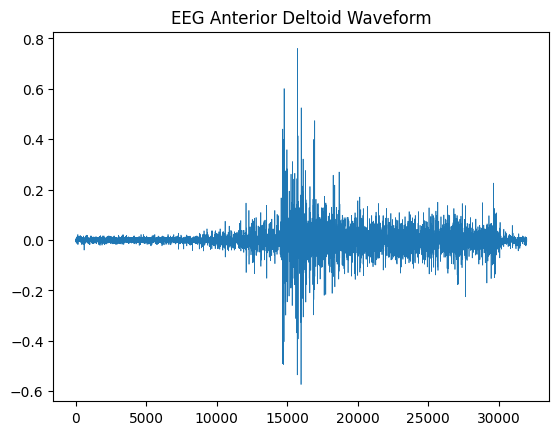

In [11]:
# 验证 tensor
plt.plot(ws.win.emg.tensor[0, :32000, 4], linewidth=0.5)  # 通道 0 波形
plt.title("EMG Anterior Deltoid Waveform")
plt.show()